## Imports das Bibliotecas

In [167]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
import nltk
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Analise dos dados

In [168]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "ementaDetalhada", "orgão", "ementa.1", "keywords.1", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7107 entries, 0 to 7405
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ementa            7107 non-null   object
 1   keywords          3877 non-null   object
 2   nome              7107 non-null   object
 3   sexo              7107 non-null   object
 4   nascimento        7107 non-null   object
 5   local_nascimento  7107 non-null   object
 6   escolaridade      6936 non-null   object
 7   situacao          1540 non-null   object
 8   tipo              1679 non-null   object
 9   cor               7107 non-null   object
dtypes: object(10)
memory usage: 610.8+ KB


In [169]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

C:\Users\alexa\AppData\Local\Temp\ipykernel_30376\1803048690.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["

In [170]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_30376\188054785.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (


In [171]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,2134
1,OUTROS,1116


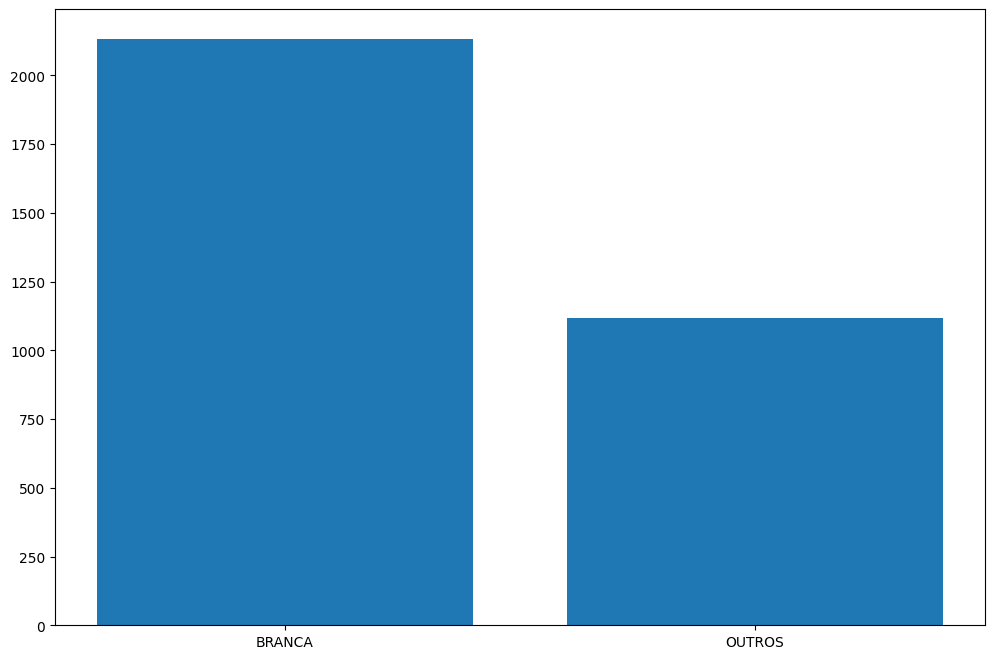

In [172]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [173]:
df["ementa"].dropna().count()

3250

## Bag Of Words

In [174]:
# nltk.download('stopwords')

In [175]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [176]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab

array(['00', '000', '0001', ..., 'única', 'único', 'útero'], dtype=object)

## WORD CLOUD

In [177]:
le = LabelEncoder()

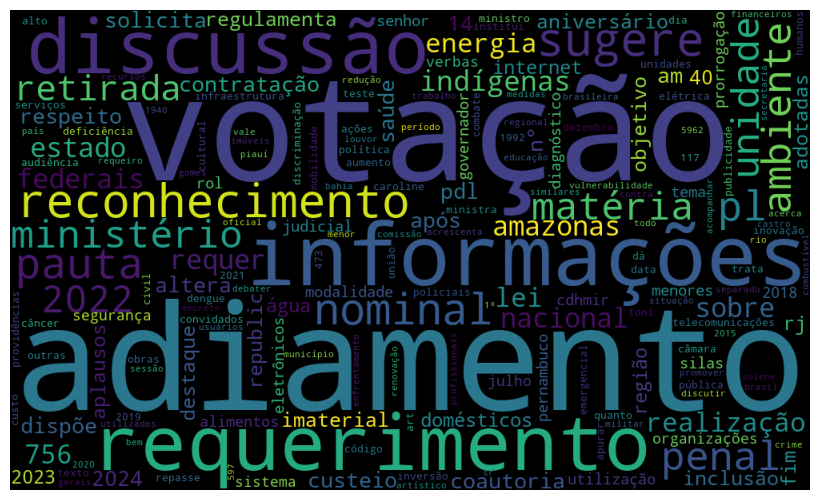

In [178]:
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)
y = le.fit_transform(df["cor"])
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

In [179]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros = df[df["cor"] == "OUTROS"]

tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )

y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])

In [180]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()


In [181]:
X_outros = tf_idf_outros.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf_outros.get_feature_names_out()



## GRUPO 1: PESSOA DE COR DE PELE BRANCA

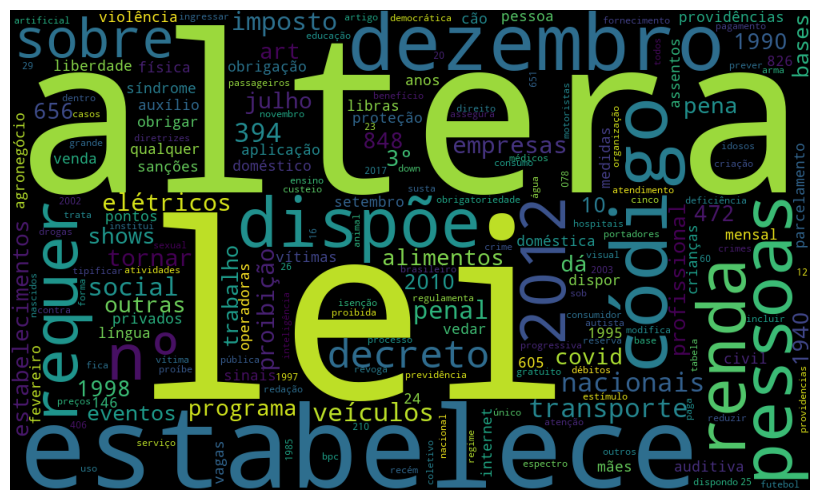

In [182]:
model_brancos = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_brancos, y_brancos)
model_brancos.fit(X_train, y_train)
features_importance = model_brancos.feature_importances_
features_name = tf_idf_brancos.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_brancos = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_brancos) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

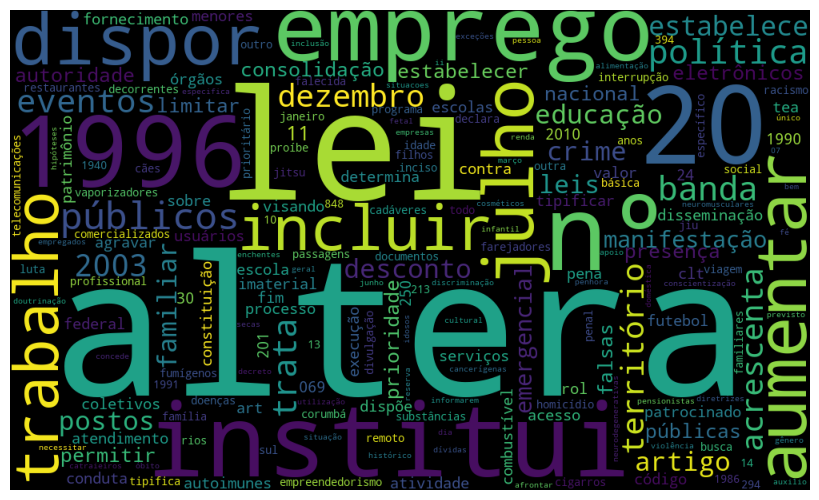

In [183]:
model_outros = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_outros, y_outros)
model_outros.fit(X_train, y_train)
features_importance = model_outros.feature_importances_
features_name = tf_idf_outros.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_outros = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_outros) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## PCA

In [184]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

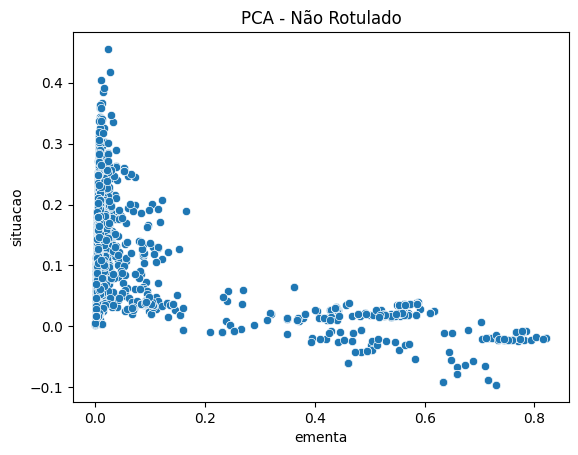

In [185]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

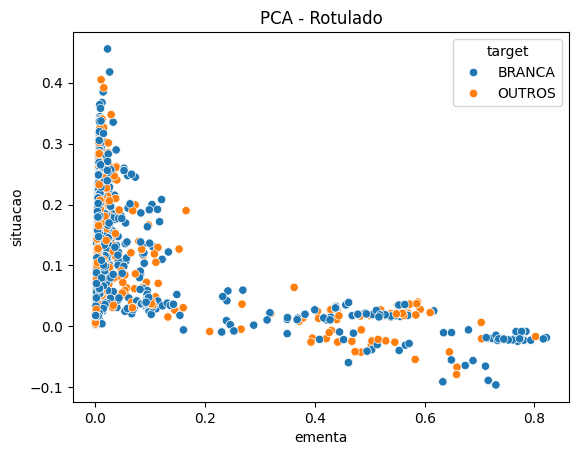

In [186]:
y_map = {0: 'BRANCA', 1: "OUTROS"}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [200]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [202]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [203]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42) 

# Logistic Regression

In [204]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=100, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.79034955 0.80326898 0.76911278 0.76541702 0.81102064]
Media da MACRO F1:  0.7878337936479619
Desvio Padrão da MACRO F1:  0.018084202065565196


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       442
           1       0.77      0.80      0.79       412

    accuracy                           0.79       854
   macro avg       0.79      0.79      0.79       854
weighted avg       0.79      0.79      0.79       854



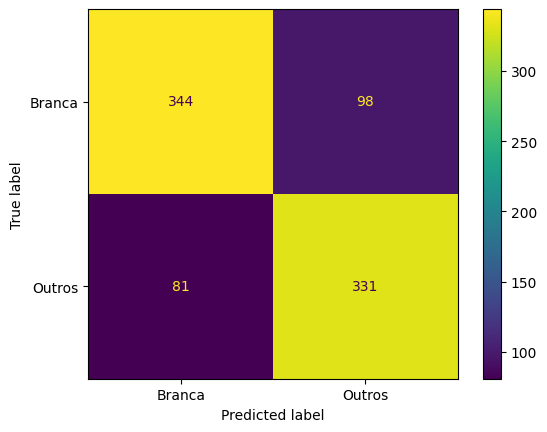

In [205]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [206]:
model_SGD = SGDClassifier(random_state=42, alpha=0.001, learning_rate="optimal")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.72707323 0.74751818 0.68474662 0.70560992 0.74847558]
Media da MACRO F1:  0.7226847053019108
Desvio Padrão da MACRO F1:  0.024625095030711232


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.69      0.89      0.78       442
           1       0.83      0.57      0.68       412

    accuracy                           0.74       854
   macro avg       0.76      0.73      0.73       854
weighted avg       0.76      0.74      0.73       854



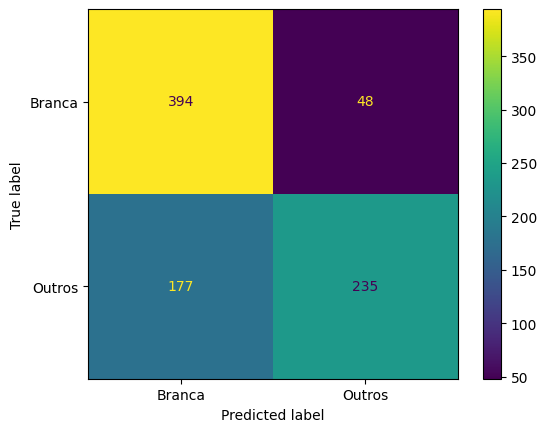

In [207]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [222]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=10, weights="distance", algorithm="auto", leaf_size=50, p=2)
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.48948264 0.51104851 0.52694265 0.51122874 0.52401143]
Media da MACRO F1:  0.5125427921878741
Desvio Padrão da MACRO F1:  0.013225853291326743


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.88      0.18      0.29       442
           1       0.52      0.97      0.68       412

    accuracy                           0.56       854
   macro avg       0.70      0.57      0.49       854
weighted avg       0.71      0.56      0.48       854



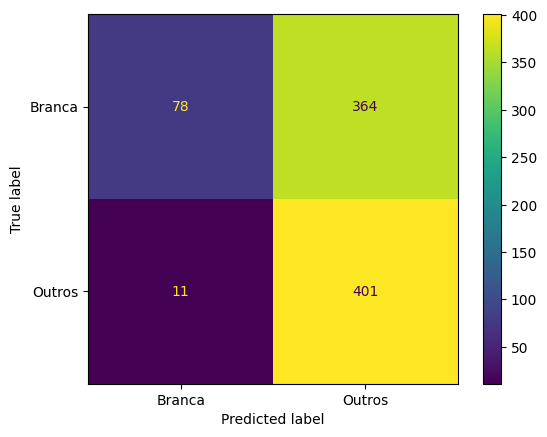

In [223]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [210]:
model_SVM = LinearSVC(penalty="l2", loss='squared_hinge', tol=0.001, C=10, multi_class='ovr', dual=True)
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.81555202 0.81488676 0.78572904 0.7796094  0.81840627]
Media da MACRO F1:  0.802836699761567
Desvio Padrão da MACRO F1:  0.01662211979548384


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       442
           1       0.76      0.91      0.83       412

    accuracy                           0.82       854
   macro avg       0.83      0.82      0.82       854
weighted avg       0.83      0.82      0.82       854



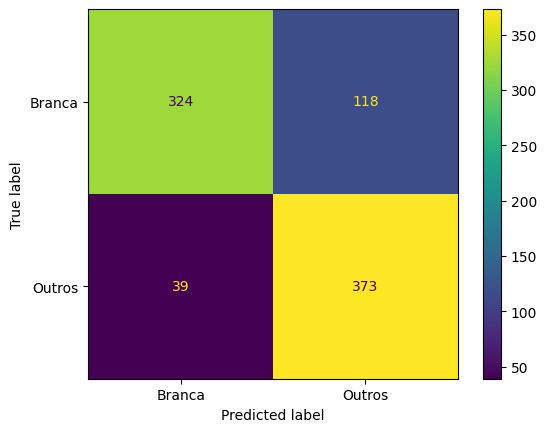

In [211]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [212]:
model_Random_Forest = RandomForestClassifier( n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.3)
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.78631802 0.81335038 0.78100612 0.7945526  0.80234149]
Media da MACRO F1:  0.795513721315311
Desvio Padrão da MACRO F1:  0.011495388653923523


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       442
           1       0.79      0.76      0.78       412

    accuracy                           0.79       854
   macro avg       0.79      0.79      0.79       854
weighted avg       0.79      0.79      0.79       854



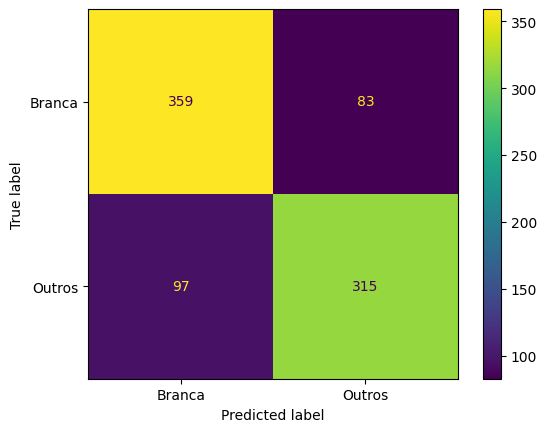

In [213]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [214]:
model_Decision_Tree = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)
cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")

print("Resultado da Cross Validation: ", cross_val_results)
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.67548304 0.70760752 0.67570334 0.69372818 0.70971827]
Media da MACRO F1:  0.6924480706280501
Desvio Padrão da MACRO F1:  0.014818267900272382


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       442
           1       0.69      0.61      0.65       412

    accuracy                           0.68       854
   macro avg       0.68      0.68      0.68       854
weighted avg       0.68      0.68      0.68       854



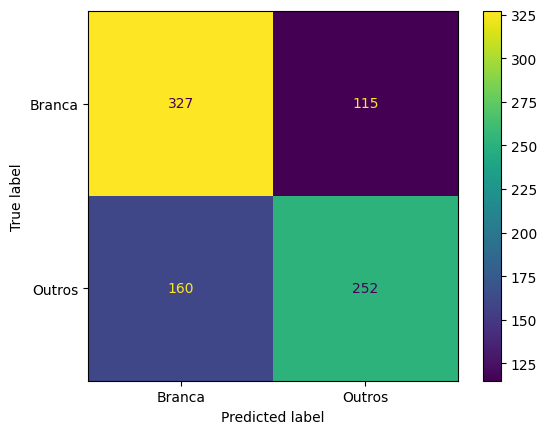

In [215]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)